In [10]:
import pandas as pd
import polars as pl
from glob import glob
from pathlib import Path
import tempfile
from PIL import Image
import io

from _analysis import get_fid
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

mpl.rcParams.update({"text.usetex": True, "font.size": 18,})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Human Realism Data

In [3]:
human_data = pd.read_csv("RQ4_anonymized.csv")
human_data.columns = [c.split(".")[0] if "." in c else c for c in human_data.columns]
valid_data = human_data[human_data['TAKE'] == 'Y']

In [4]:
selected_cols = valid_data.iloc[:, 1:-1]  # Get questions only
lr_map = {c: int(c[0])*10**(-int(c[1])) for c in selected_cols.columns.unique()}  # Remove attention questions (99).
data_map = {v: None for v in lr_map.values()}

for col in selected_cols.columns.unique():
    data_map[lr_map[col]] = selected_cols[col].stack().dropna().tolist()

##  Load Dataset

In [5]:
path = Path("imagenet_full.parquet")
if not path.exists():
    df = pl.read_parquet('hf://datasets/ILSVRC/imagenet-1k/data/validation-*.parquet')
    df = df.with_columns([
        pl.col("image").struct.field("bytes").alias("image_bytes"),
        pl.col("image").struct.field("path").alias("image_filename")
    ])
    df.write_parquet(path)
else:
    df = pl.read_parquet(path)

tmp_dir = Path(tempfile.mkdtemp())
imagenet_paths = []
for row in df.iter_rows(named=True):
    img = Image.open(io.BytesIO(row["image_bytes"])).convert("RGB")
    if img.size != (256, 256):
        img = img.resize((256, 256), Image.BILINEAR)
    path_file = tmp_dir / (Path(row["image_filename"]).stem + ".jpg")
    img.save(path_file, format="JPEG", quality=95)
    imagenet_paths.append(str(path_file))

## Calculate FID Scores

In [6]:
sweep_path = "/home/weissl/Projects/SMOO/defaults/hynea/_sweep/"
fid_by_lr = {}

for lr_dir in glob(f"{sweep_path}/*_runs"):
    lr_config = lr_dir.split("/")[-1].replace("_runs", "")
    targets = sorted(glob(f"{lr_dir}/*/*/taget*.png"))
    
    if targets:
        fid_score = get_fid(imagenet_paths, targets)
        fid_by_lr[lr_config]  = float(fid_score)

100%|██████████| 391/391 [01:19<00:00,  4.90it/s]


100%|██████████| 1/1 [00:00<00:00,  1.80it/s]


100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


100%|██████████| 1/1 [00:00<00:00,  1.87it/s]


100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


100%|██████████| 1/1 [00:00<00:00,  1.82it/s]


100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


100%|██████████| 1/1 [00:00<00:00,  1.81it/s]


In [7]:
key_map = {float(k.split("_")[0]):k for k in fid_by_lr.keys()}

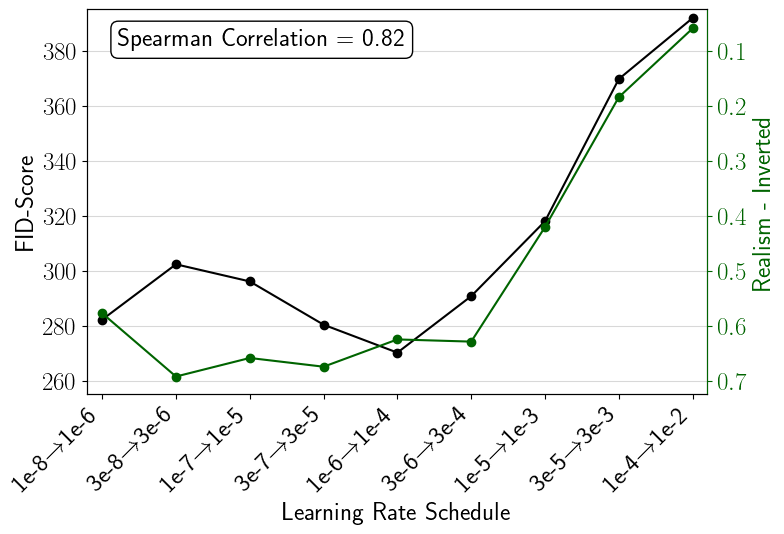

In [40]:
fig, ax = plt.subplots(1,1, figsize=(8,5))

data_r, data_q = [], []
lower_err_r, upper_err_r = [], []
lower_err_q, upper_err_q = [], []
ticks = []

for kr, kq in zip(sorted(key_map.keys()), sorted(data_map.keys())):
    vals_r = np.array(fid_by_lr[key_map[kr]])
    vals_q = (np.array(data_map[kq])-1) / 4  # Normalize scale from 0-1 (was 1-5)

    mean_r = vals_r.mean()
    mean_q = vals_q.mean()

    data_r.append(mean_r)
    data_q.append(mean_q)

    ticks.append(r"$\rightarrow$".join(key_map[kr].split("_")))
yerr_r = [lower_err_r, upper_err_r]
yerr_q = [lower_err_q, upper_err_q]

ax.plot([v for v in range(len(data_r))], data_r,"o",  color="black")
ax.plot([v for v in range(len(data_r))], data_r,  color="black")
ax.set_ylabel("FID-Score")
ax.tick_params(axis="y")
ax.set_ylim(255, 395)


ax2 = ax.twinx()
ax2.set_ylabel("Realism - Inverted", color="darkgreen")
ax2.tick_params(axis="y", colors="darkgreen")
ax2.spines["right"].set_color("darkgreen")
ax2.plot([v for v in range(len(data_q))], data_q, "o", color="darkgreen")
ax2.plot([v for v in range(len(data_q))], data_q, color="darkgreen")
ax2.set_ylim(0.025, 0.725)
ax2.invert_yaxis()

"""Correlation"""
corr, _ = spearmanr(list(fid_by_lr.values()), [np.mean(v) for v in data_map.values()])

ax.set_xlim([-0.2,len(data_r)-0.8])
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.grid(axis="y", color="grey", alpha=0.3)

ax2.yaxis.set_major_locator(MaxNLocator(nbins=8))

ax.set_xticks(range(len(data_r)))
ax.set_xticklabels(ticks, rotation=45, ha="right")
ax.set_xlabel("Learning Rate Schedule")

plt.text(0.05, 0.95, f"Spearman Correlation = {np.mean(corr):.2f}",
         transform=plt.gca().transAxes,  # coordinates relative to axes
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white'))

plt.savefig("figures/sweep_qual_corr.pdf", dpi=200, bbox_inches="tight")